# 03 — Pareto: Low-Cost vs Commercial

Load one processed synthetic run and reproduce the paper-style Pareto-front and split-violin comparisons. Scenario grouping comes directly from NetCDF coordinates; no legacy test numbers, date labels, or expected-data files are required.

## Setup

In [155]:
import json
import os
import pathlib
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")
sns.set_theme(style="ticks")

CWD = pathlib.Path.cwd().resolve()
for candidate in [CWD, *CWD.parents]:
    if (candidate / "pyproject.toml").exists():
        REPO_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the repository root containing pyproject.toml.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from soilgasflux_fcs import pareto

PROCESSED_RUNS_ROOT = REPO_ROOT / "notebooks" / "processing" / "output" / "03_synthetic_runs"
FIGURE_RUNS_ROOT = REPO_ROOT / "notebooks" / "post_processing" / "figures" / "03_synthetic_runs"
CM = 1 / 2.54


## Configuration

In [156]:
# RUN_ID = os.environ.get("SOILGASFLUX_RUN_ID") or None
RUN_ID = None

INTENSITY_ORDER = ["low", "medium", "high"]
PARETO_CURVE_ORDER = ["linear", "convex"]
VIOLIN_CURVE_ORDER = ["convex", "linear"]
SENSOR_ORDER = ["low-cost", "commercial"]
SENSOR_LABELS = {"low-cost": "Low-cost", "commercial": "Commercial"}
COLORS = {
    # "low-cost": sns.color_palette("coolwarm", n_colors=2)[0],
    # "commercial": sns.color_palette("coolwarm", n_colors=2)[1],
    "low-cost": "#15e43e",
    "commercial": "#e71212",
}

    # "commercial": "#e71212",
    # "low-cost": "#15e43e",
# Leave limits as None to derive bounds from the current Pareto fronts.
# Explicit tuples remain available when an exact paper axis range is required.
PARETO_XLIM = None
PARETO_YLIM = None
# PARETO_Y_SCALE = "log"
PARETO_Y_SCALE = "linear"
VIOLIN_Y_RANGES = None

FIXED_CONFIGS = [
    {"deadband": 0, "cutoff": 60, "marker": "s", "label": "Arbitrary 1", "color": "black"},
    {"deadband": 20, "cutoff": 80, "marker": "^", "label": "Arbitrary 2", "color": "green"},
    {"deadband": 20, "cutoff": 170, "marker": "o", "label": "Arbitrary 3", "color": "orange"},
]


## Load and Validate Processed Outputs

In [157]:
def read_json(path):
    with pathlib.Path(path).open(encoding="utf-8") as handle:
        return json.load(handle)


def resolve_processed_run(root, run_id):
    if run_id:
        run_dir = root / run_id
        if not (run_dir / "processing_manifest.json").exists():
            raise FileNotFoundError(
                f"Processed run {run_id!r} does not contain processing_manifest.json: {run_dir}"
            )
        return run_dir
    candidates = sorted(
        path for path in root.glob("*")
        if path.is_dir() and (path / "processing_manifest.json").exists()
    )
    if not candidates:
        raise FileNotFoundError(
            f"No processed runs were found in {root}. Run 03_process_synthetic_batch.ipynb first."
        )
    return candidates[-1]


def open_loaded(path):
    if not path.exists():
        raise FileNotFoundError(f"Missing required processed file: {path}")
    with xr.open_dataset(path) as opened:
        return opened.load()


def validate_dataset(ds, sensor_type, kind):
    required_coords = {"time", "cutoff", "deadband", "scenario_id", "curve_type", "intensity"}
    if kind == "mcmc":
        required_coords.add("MC")
    missing_coords = required_coords - set(ds.coords)
    if missing_coords:
        raise ValueError(f"{sensor_type}/{kind} is missing coordinates: {sorted(missing_coords)}")
    required_vars = {"dcdt(HM)"}
    if kind == "mcmc":
        required_vars.add("logprob(HM)")
    missing_vars = required_vars - set(ds.data_vars)
    if missing_vars:
        raise ValueError(f"{sensor_type}/{kind} is missing variables: {sorted(missing_vars)}")
    if ds.attrs.get("sensor_type") != sensor_type:
        raise ValueError(
            f"Sensor attribute mismatch for {sensor_type}/{kind}: {ds.attrs.get('sensor_type')!r}"
        )
    combinations = set(zip(ds["curve_type"].values.tolist(), ds["intensity"].values.tolist()))
    expected = {(curve, intensity) for curve in PARETO_CURVE_ORDER for intensity in INTENSITY_ORDER}
    if combinations != expected:
        raise ValueError(
            f"{sensor_type}/{kind} scenario combinations are incomplete: {sorted(combinations)}"
        )


processed_run_dir = resolve_processed_run(PROCESSED_RUNS_ROOT, RUN_ID)
processing_manifest = read_json(processed_run_dir / "processing_manifest.json")
if processing_manifest.get("schema_version") != 1:
    raise ValueError(
        f"Unsupported processing manifest schema: {processing_manifest.get('schema_version')!r}"
    )
run_id = processing_manifest["run_id"]
figure_run_dir = FIGURE_RUNS_ROOT / run_id
figure_run_dir.mkdir(parents=True, exist_ok=True)

data = {"regular": {}, "mcmc": {}}
for sensor_type in ["base", "commercial", "low-cost"]:
    sensor_files = processing_manifest.get("sensors", {}).get(sensor_type)
    if sensor_files is None:
        raise ValueError(f"Processing manifest has no entry for sensor {sensor_type!r}.")
    for kind in ["regular", "mcmc"]:
        filename = sensor_files.get(kind)
        if not filename:
            raise ValueError(f"Processing manifest has no {kind!r} output for {sensor_type!r}.")
        ds = open_loaded(processed_run_dir / filename)
        validate_dataset(ds, sensor_type, kind)
        data[kind][sensor_type] = ds

reference_times = data["regular"]["base"]["time"].values
for kind in ["regular", "mcmc"]:
    for sensor_type, ds in data[kind].items():
        if not np.array_equal(ds["time"].values, reference_times):
            raise ValueError(f"Time coordinates are not aligned for {sensor_type}/{kind}.")

for sensor_type in SENSOR_ORDER:
    ds = data["mcmc"][sensor_type]
    available_deadbands = set(ds["deadband"].values.tolist())
    available_cutoffs = set(ds["cutoff"].values.tolist())
    for config in FIXED_CONFIGS:
        if config["deadband"] not in available_deadbands or config["cutoff"] not in available_cutoffs:
            raise ValueError(
                f"Fixed configuration DB={config['deadband']}, CO={config['cutoff']} "
                f"is unavailable for {sensor_type}."
            )

print(f"Loaded processed run: {processed_run_dir}")
print(f"Figures will be saved to: {figure_run_dir}")


Loaded processed run: /Users/alexnaokiasatokobayashi/git/soilgasflux_fcs/notebooks/processing/output/03_synthetic_runs/20260805T102850365113Z
Figures will be saved to: /Users/alexnaokiasatokobayashi/git/soilgasflux_fcs/notebooks/post_processing/figures/03_synthetic_runs/20260805T102850365113Z


## Pareto Helpers

In [158]:
def select_group_times(ds, intensity, curve_type):
    mask = (ds["intensity"] == intensity) & (ds["curve_type"] == curve_type)
    selected = ds["time"].where(mask, drop=True).values
    if len(selected) == 0:
        raise ValueError(f"No scenarios found for curve={curve_type!r}, intensity={intensity!r}.")
    return selected


def pareto_result(dsMC, time_selection):
    selected = dsMC.sel(time=time_selection).median(dim="time")
    pa = pareto.Pareto(dsMC=selected)
    with np.errstate(divide="ignore", invalid="ignore"):
        norm_u, norm_l, flat_u, flat_l = pa.prepare_metrics()
    finite = np.isfinite(flat_u) & np.isfinite(flat_l)
    if not finite.any():
        raise ValueError("Pareto metrics contain no finite cutoff/deadband combinations.")
    pareto_indices = pa.find_pareto_front(
        x=flat_u,
        y=flat_l,
        maximize_x=False,
        maximize_y=False,
    )
    if len(pareto_indices) == 0:
        raise ValueError("No Pareto front could be identified for the selected group.")
    coords = pa.get_coords_pareto(pareto_indices)
    best_x, best_y = pa.get_best_from_pareto(
        pareto_indices=pareto_indices,
        metric_x=norm_u,
        metric_y=norm_l,
    )
    raw_uncertainty = pa.uncertaintyRange.values
    raw_logprob = pa.logprob.values
    if not np.isfinite(raw_uncertainty[best_x, best_y]) or not np.isfinite(raw_logprob[best_x, best_y]):
        raise ValueError("The selected Pareto compromise is not finite.")
    return {
        "uncertainty": raw_uncertainty,
        "logprob": raw_logprob,
        "pareto_uncertainty": raw_uncertainty[coords],
        "pareto_logprob": raw_logprob[coords],
        "best_uncertainty": raw_uncertainty[best_x, best_y],
        "best_logprob": raw_logprob[best_x, best_y],
        "best_x": best_x,
        "best_y": best_y,
        "best_cutoff": selected.coords["cutoff"][best_x].item(),
        "best_deadband": selected.coords["deadband"][best_y].item(),
    }


def build_pareto_data(processed_data):
    result = {"commercial": {}, "low-cost": {}}
    for sensor_type in ["commercial", "low-cost"]:
        dsMC = processed_data["mcmc"][sensor_type]
        for intensity in INTENSITY_ORDER:
            for curve_type in PARETO_CURVE_ORDER:
                times = select_group_times(dsMC, intensity, curve_type)
                result[sensor_type][f"{intensity}_{curve_type}"] = pareto_result(dsMC, times)
    return result


## Figure 1: Pareto Front Comparison

In [162]:
def plot_pareto_comparison(pareto_data):
    front_x = np.concatenate(
        [
            np.asarray(result["pareto_uncertainty"]).ravel()
            for sensor_data in pareto_data.values()
            for result in sensor_data.values()
        ]
    )
    front_y = np.concatenate(
        [
            np.asarray(result["pareto_logprob"]).ravel()
            for sensor_data in pareto_data.values()
            for result in sensor_data.values()
        ]
    )
    front_x = front_x[np.isfinite(front_x)]
    front_y = front_y[np.isfinite(front_y)]
    if len(front_x) == 0 or len(front_y) == 0:
        raise ValueError("No finite Pareto-front values are available for plotting.")

    x_span = float(front_x.max() - front_x.min()) or max(float(front_x.max()), 1.0)
    x_limits = PARETO_XLIM or (
        max(0.0, float(front_x.min()) - 0.08 * x_span),
        float(front_x.max()) + 0.15 * x_span,
    )
    if PARETO_YLIM is not None:
        y_limits = PARETO_YLIM
    elif PARETO_Y_SCALE == "log":
        positive_y = front_y[front_y > 0]
        if len(positive_y) == 0:
            raise ValueError("Logarithmic Pareto plotting requires positive log-probability metrics.")
        y_limits = (float(positive_y.min()) * 0.75, float(positive_y.max()) * 1.5)
    else:
        y_span = float(front_y.max() - front_y.min()) or max(abs(float(front_y.max())), 1.0)
        y_limits = (
            float(front_y.min()) - 0.08 * y_span,
            float(front_y.max()) + 0.15 * y_span,
        )

    fig, axes = plt.subplots(2, 3, figsize=(19 * CM, 12 * CM), sharey=True, dpi=300)
    for row, curve_type in enumerate(PARETO_CURVE_ORDER):
        for col, intensity in enumerate(INTENSITY_ORDER):
            ax = axes[row, col]
            key = f"{intensity}_{curve_type}"
            for sensor_type in ["commercial", "low-cost"]:
                result = pareto_data[sensor_type][key]
                ax.scatter(
                    result["uncertainty"].ravel(),
                    result["logprob"].ravel(),
                    s=3,
                    c=[COLORS[sensor_type]],
                    alpha=0.3,
                )
                ax.scatter(
                    result["pareto_uncertainty"],
                    result["pareto_logprob"],
                    s=15,
                    c=[COLORS[sensor_type]],
                    alpha=0.8,
                    marker="o",
                    edgecolors="k",
                    linewidth=0.5,
                    zorder=5,
                )
                ax.scatter(
                    result["best_uncertainty"],
                    result["best_logprob"],
                    s=80,
                    c=[COLORS[sensor_type]],
                    alpha=0.9,
                    marker="*",
                    edgecolors="k",
                    linewidth=1,
                    zorder=10,
                )

            ax.set_xlim(x_limits)
            ax.set_yscale(PARETO_Y_SCALE)
            ax.set_ylim(y_limits)
            ax.set_title(
                f"Curve type: {curve_type}\nFlux intensity: {intensity}",
                fontsize=12,
            )
            if row == 1:
                ax.set_xlabel("Uncertainty Range", fontsize=11)
            if col == 0:
                ax.set_ylabel("Log Probability", fontsize=11)

            for sensor_type in ["low-cost", "commercial"]:
                result = pareto_data[sensor_type][key]
                x_best = result["best_uncertainty"]
                y_best = result["best_logprob"]
                x_range = ax.get_xlim()[1] - ax.get_xlim()[0]
                x_low, x_high = ax.get_xlim()
                x_margin = x_range * 0.03
                if sensor_type == "commercial":
                    x_text = min(x_high - x_margin, x_best + x_range * 0.22)
                    y_text = y_best * 1.45 if PARETO_Y_SCALE == "log" else y_best + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.05
                else:
                    x_text = min(x_high - x_margin, x_best + x_range * 0.04)
                    y_text = y_best * 2.2 if PARETO_Y_SCALE == "log" else y_best + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.25
                if PARETO_Y_SCALE == "log":
                    y_text = min(y_text, ax.get_ylim()[1] / 2.0)
                ax.annotate(
                    f"CO: {result['best_cutoff']:.0f}\nDB: {result['best_deadband']:.0f}",
                    xy=(x_best, y_best),
                    xytext=(x_text, y_text),
                    fontsize=7,
                    ha="center",
                    va="center",
                    bbox=dict(
                        boxstyle="round,pad=0.2",
                        facecolor=COLORS[sensor_type],
                        alpha=0.2,
                        edgecolor=COLORS[sensor_type],
                    ),
                    arrowprops=dict(
                        arrowstyle="->",
                        connectionstyle="arc3,rad=0.1",
                        color="grey",
                        lw=1,
                    ),
                    zorder=15,
                )

    legend_handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=COLORS["commercial"], markersize=6, alpha=0.6, label="Sensor precision: 10 ppm"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor=COLORS["low-cost"], markersize=6, alpha=0.6, label="Sensor precision: 5 ppm"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="none", markersize=6, markeredgecolor="k", linewidth=0.5, label="Pareto front"),
        Line2D([0], [0], marker="*", color="w", markerfacecolor="none", markersize=10, markeredgecolor="k", linewidth=1, label="$d_{min}$"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="center left",
        bbox_to_anchor=(0.35, -0.02),
        fontsize=9,
        title_fontsize=10,
        ncols=2,
    )
    fig.tight_layout()
    return fig


## Figure 2: dC/dt Split Violins

In [169]:
def violin_group_dataframe(dsMC_low, dsMC_com, time_selection):
    rows = []
    for sensor_type, dsMC in [("low-cost", dsMC_low), ("commercial", dsMC_com)]:
        result = pareto_result(dsMC, time_selection)
        values = (
            dsMC.sel(
                time=time_selection,
                deadband=result["best_deadband"],
                cutoff=result["best_cutoff"],
            )["dcdt(HM)"]
            .median(dim="time")
            .values.ravel()
        )
        # filter quantile 
        values = values[(values >= np.nanquantile(values, 0.1)) & (values <= np.nanquantile(values, 0.9))]
        
        for value in values[np.isfinite(values)]:
            rows.append(
                {
                    "dcdt(HM)": value,
                    "Dataset": SENSOR_LABELS[sensor_type],
                    "sensor": sensor_type,
                    "Deadband": result["best_deadband"],
                    "Cutoff": result["best_cutoff"],
                }
            )
    frame = pd.DataFrame(rows)
    if frame.empty or set(frame["sensor"]) != set(SENSOR_ORDER):
        raise ValueError("Both low-cost and commercial MCMC samples are required for a split violin.")
    return frame


def fixed_config_value(dsMC, time_selection, deadband, cutoff):
    value = dsMC.sel(
        time=time_selection,
        deadband=deadband,
        cutoff=cutoff,
    )["dcdt(HM)"].median().item()
    if not np.isfinite(value):
        raise ValueError(f"Fixed configuration DB={deadband}, CO={cutoff} produced no finite dC/dt value.")
    return value


def plot_dcdt_comparison_violins(processed_data):
    dsMC_low = processed_data["mcmc"]["low-cost"]
    dsMC_com = processed_data["mcmc"]["commercial"]
    ds_base = processed_data["regular"]["base"]
    color_list = [COLORS["low-cost"], COLORS["commercial"]]
    fig, axes = plt.subplots(2, 3, figsize=(19 * CM, 12.5 * CM), dpi=300)

    for row, curve_type in enumerate(VIOLIN_CURVE_ORDER):
        for col, intensity in enumerate(INTENSITY_ORDER):
            ax = axes[row, col]
            time_selection = select_group_times(dsMC_low, intensity, curve_type)
            df_violin = violin_group_dataframe(dsMC_low, dsMC_com, time_selection)
            base_value = ds_base.sel(
                time=time_selection,
                deadband=0,
                cutoff=60,
            )["dcdt(HM)"].median().item()
            if not np.isfinite(base_value):
                raise ValueError(f"Base reference is not finite for {curve_type}/{intensity}.")
            ax.axhline(base_value, label="Base", color="black", linewidth=2)
            ax.set_title(
                f"Curve type: {curve_type}\nFlux intensity: {intensity}",
                fontsize=10,
            )

            sns.violinplot(
                data=df_violin,
                hue="Dataset",
                y="dcdt(HM)",
                split=True,
                palette=color_list,
                inner="quartiles",
                ax=ax,
                legend=False,
            )
            x_positions = [-0.3, 0.3]
            for index, sensor_type in enumerate(SENSOR_ORDER):
                dsMC = dsMC_low if sensor_type == "low-cost" else dsMC_com
                for config in FIXED_CONFIGS:
                    ax.scatter(
                        x_positions[index],
                        fixed_config_value(
                            dsMC,
                            time_selection,
                            config["deadband"],
                            config["cutoff"],
                        ),
                        marker=config["marker"],
                        s=30,
                        c=config["color"],
                        edgecolors="white",
                        linewidth=1,
                        alpha=0.7,
                        zorder=10,
                    )

            if VIOLIN_Y_RANGES is not None:
                ax.set_ylim(VIOLIN_Y_RANGES[col])
            ax.set_ylabel("$dCO_2/dt$" if col == 0 else "")
            ax.set_xlabel("Density" if row == 1 else "")
            # ax.set_xticks([])
            for index, sensor_type in enumerate(SENSOR_ORDER):
                sensor_data = df_violin[df_violin["sensor"] == sensor_type]
                deadband = sensor_data["Deadband"].iloc[0]
                cutoff = sensor_data["Cutoff"].iloc[0]
                low, high = ax.get_ylim()
                ax.text(
                    [-0.25, 0.25][index],
                    high - (high - low) * 0.75,
                    f"DB:{deadband:.0f}\nCO:{cutoff:.0f}",
                    ha="center",
                    va="top",
                    fontsize=8,
                    bbox=dict(
                        boxstyle="round,pad=0.3",
                        facecolor=color_list[index],
                        alpha=0.8,
                    ),
                    zorder=10,
                )

    legend_elements = [
        Patch(facecolor=COLORS["low-cost"], label="Sensor precision: 5 ppm", alpha=1),
        Patch(facecolor=COLORS["commercial"], label="Sensor precision: 10 ppm", alpha=1),
        Line2D([0], [0], color="black", linestyle="-", linewidth=1, label="Base (DB:0, CO:60)"),
    ]
    for config in FIXED_CONFIGS:
        legend_elements.append(
            Line2D(
                [0],
                [0],
                marker=config["marker"],
                color="w",
                markerfacecolor=config["color"],
                markersize=5,
                markeredgecolor="white",
                markeredgewidth=1,
                alpha=0.7,
                label=f"{config['label']} (DB:{config['deadband']}, CO:{config['cutoff']})",
            )
        )
    fig.legend(
        handles=legend_elements,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.08),
        fontsize=8,
        title_fontsize=8,
        ncols=3,
    )
    fig.tight_layout()
    return fig


## Generate and Save Figures

OSError: Figure was not saved correctly: /Users/alexnaokiasatokobayashi/git/soilgasflux_fcs/notebooks/post_processing/figures/03_synthetic_runs/20260805T102850365113Z/pareto.png

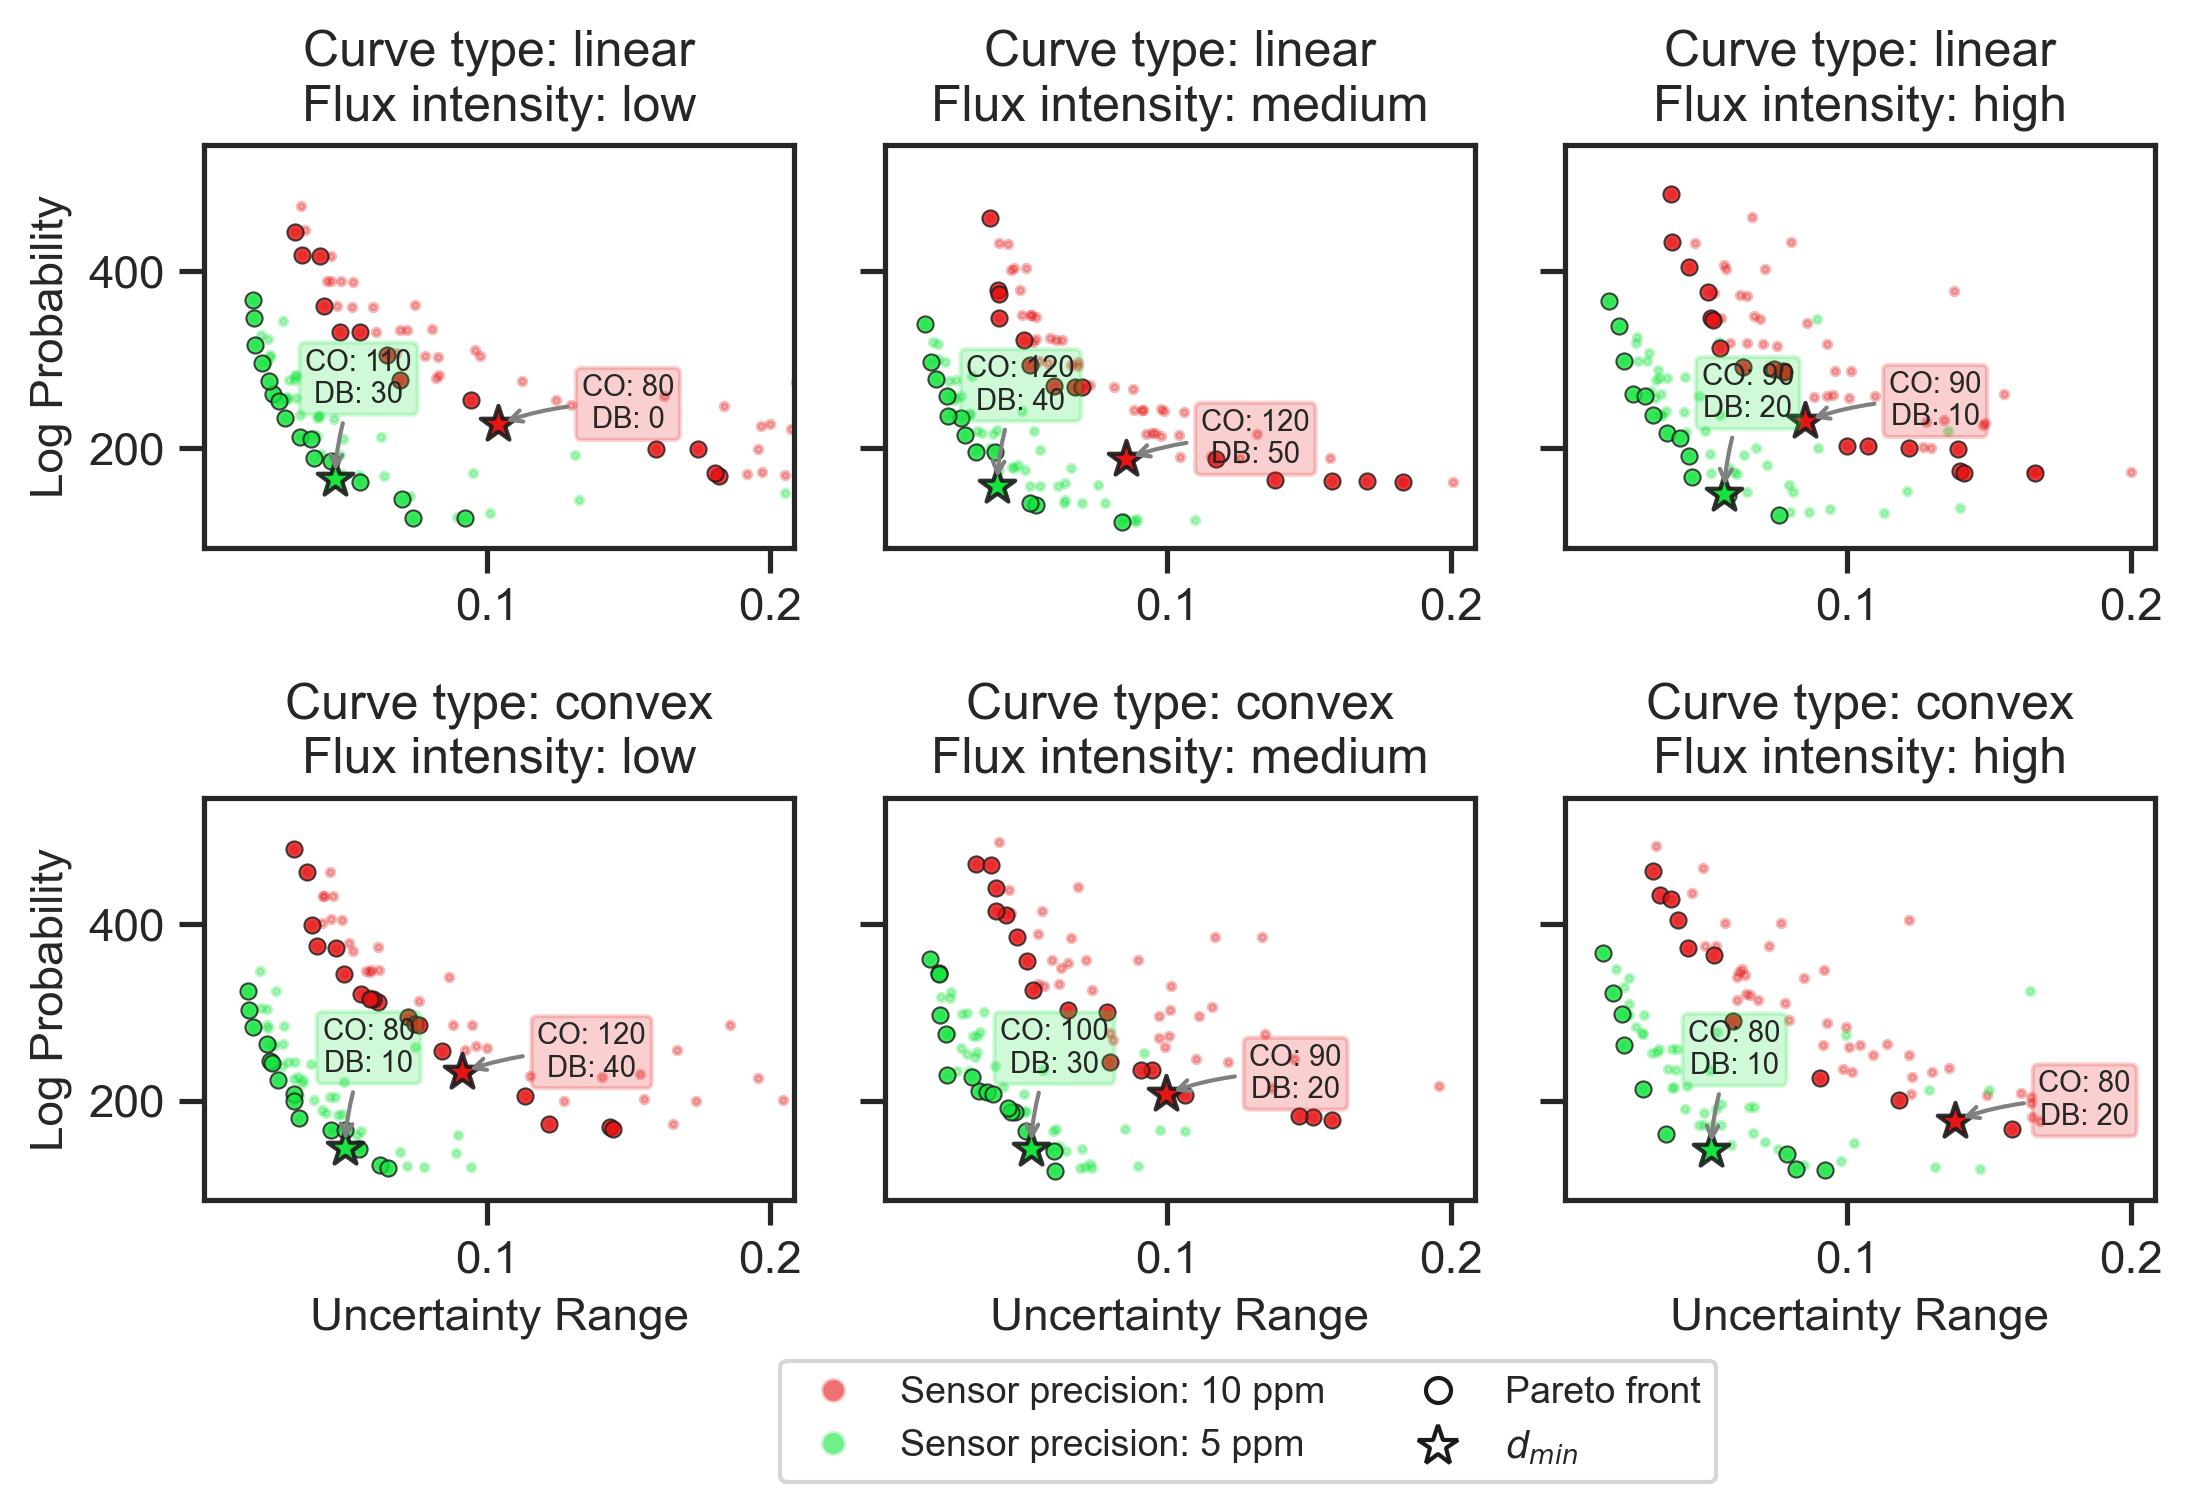

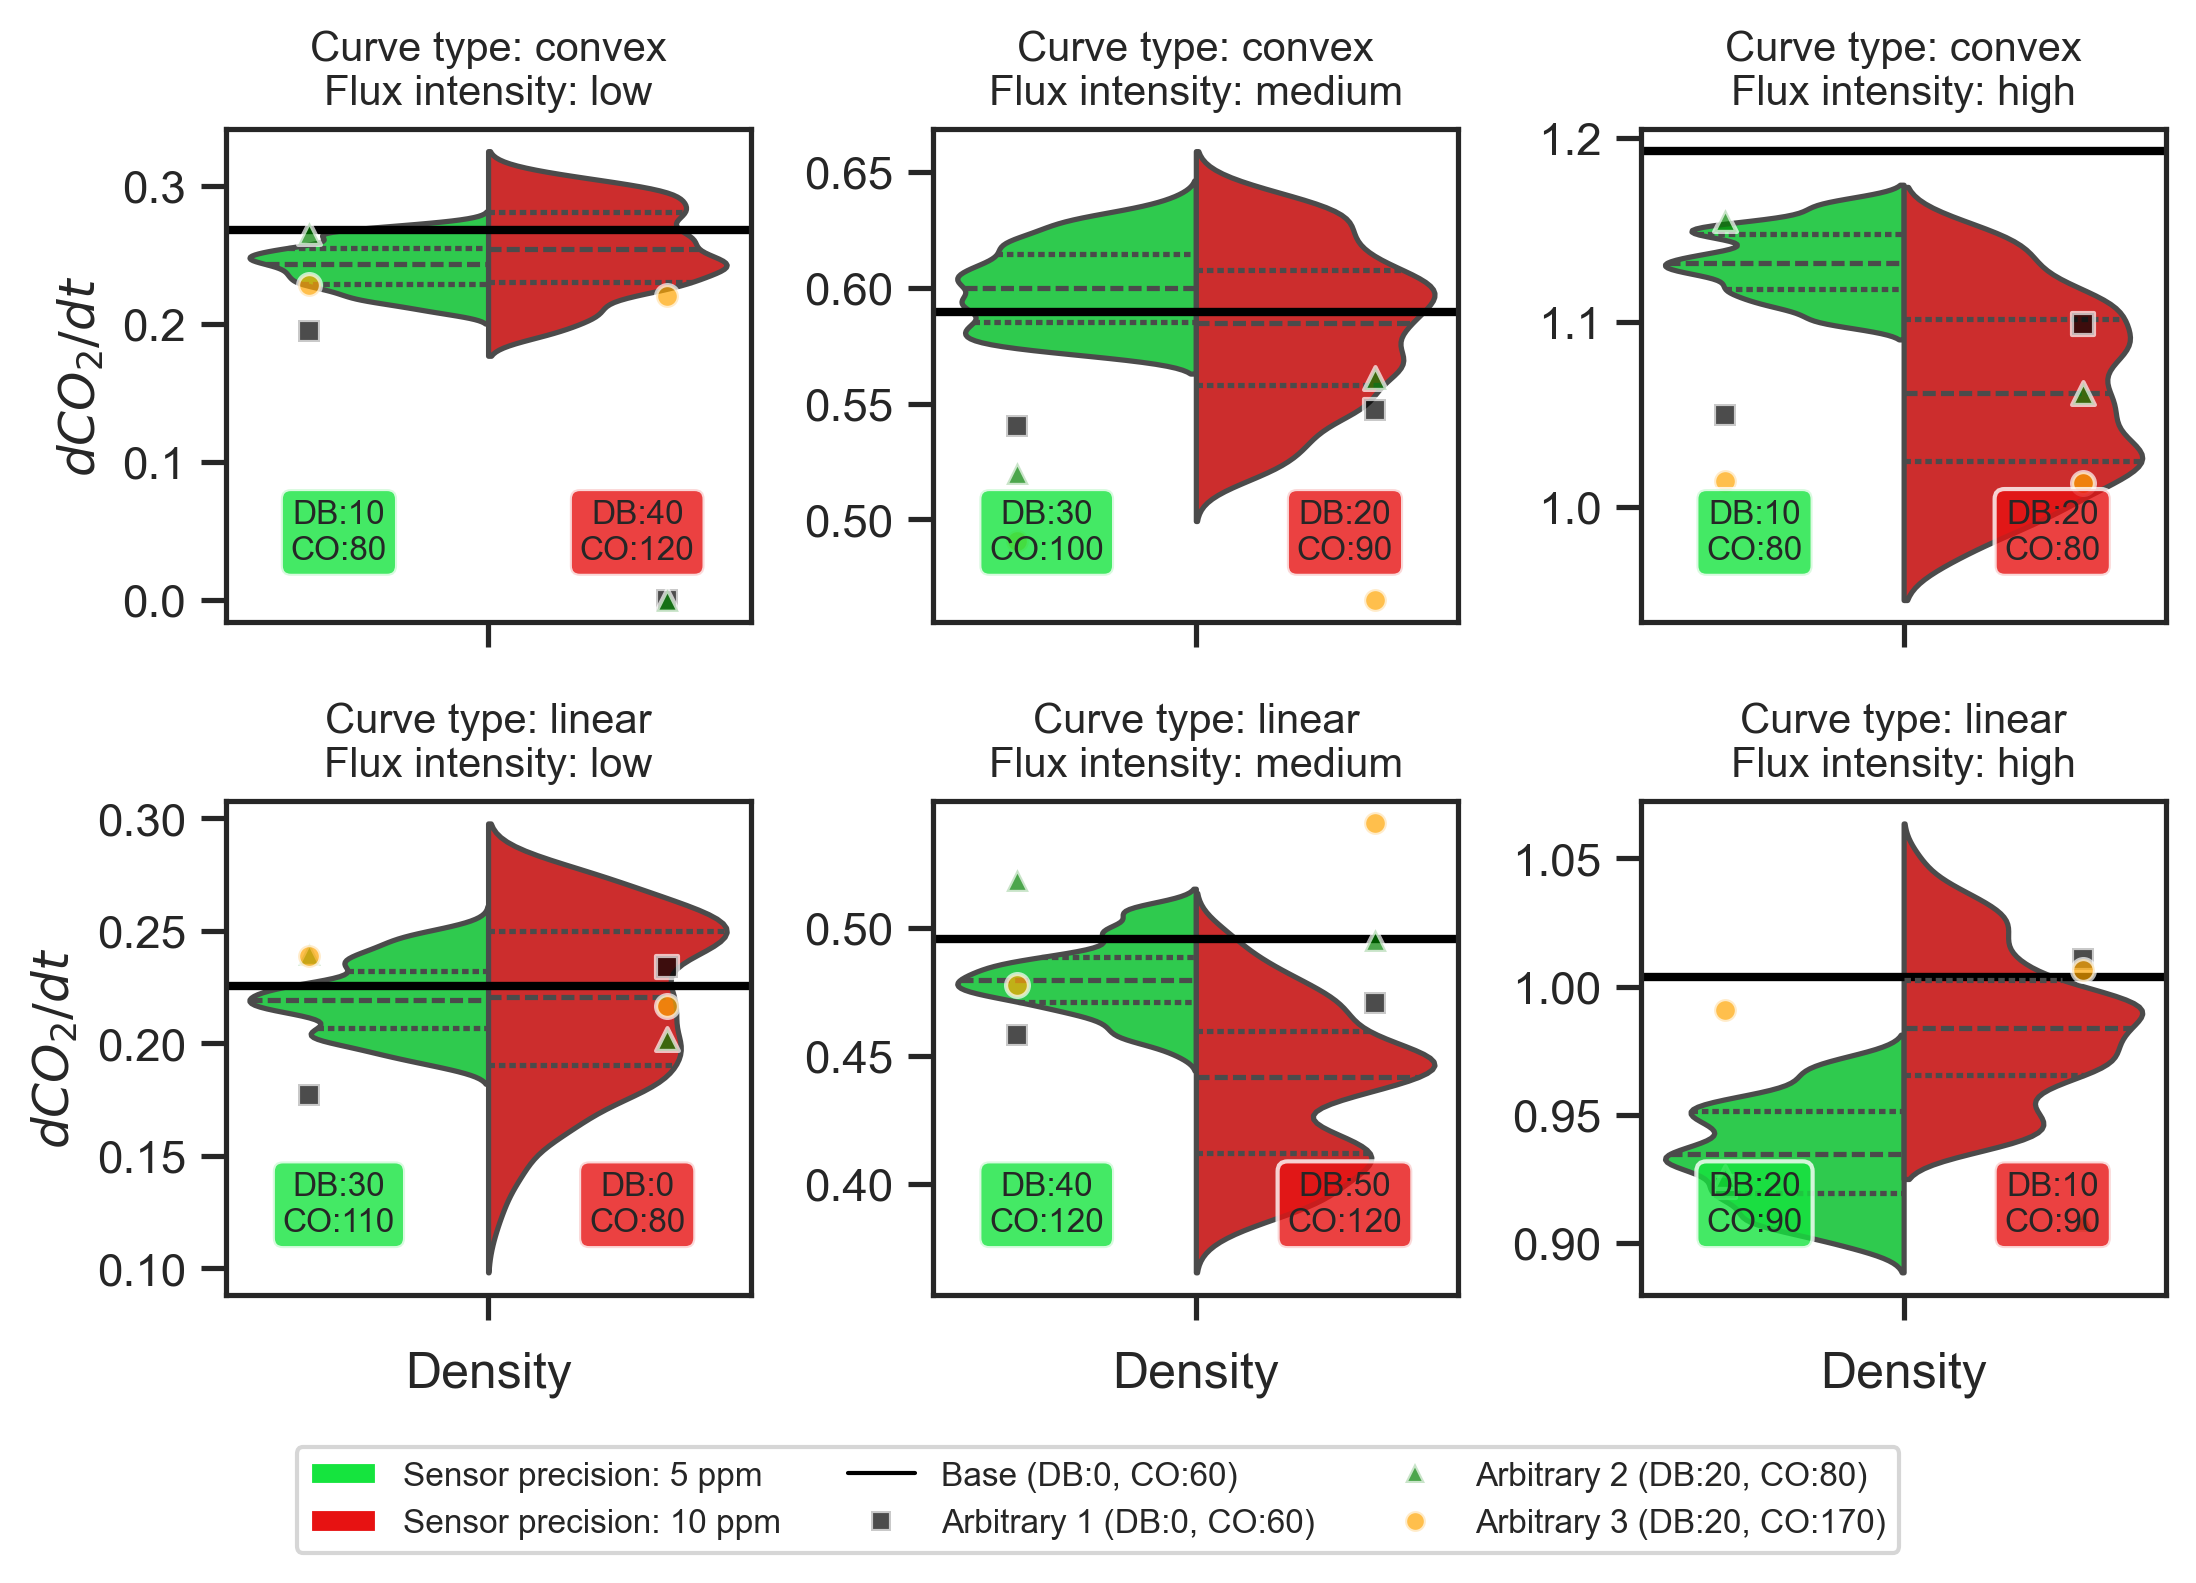

In [170]:
pareto_data = build_pareto_data(data)
pareto_fig = plot_pareto_comparison(pareto_data)
pareto_path = figure_run_dir / "pareto.png"
# pareto_fig.savefig(pareto_path, dpi=300, bbox_inches="tight")

violin_fig = plot_dcdt_comparison_violins(data)
violin_path = figure_run_dir / "dcdt_comparison_violin_plots.png"
# violin_fig.savefig(violin_path, dpi=300, bbox_inches="tight")

for path in [pareto_path, violin_path]:
    if not path.exists() or path.stat().st_size == 0:
        raise IOError(f"Figure was not saved correctly: {path}")

print(f"Saved Pareto comparison to: {pareto_path}")
print(f"Saved dC/dt comparison violins to: {violin_path}")
